# Day 2: Advanced Digital Image Processing (DIP) Techniques
This notebook implements advanced DIP methods for LULC classification, focusing on texture (GLCM, LBP) and shape (HOG) analysis.

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern, hog
from skimage import exposure

DATA_DIR = Path('../data/processed')
FIGURES_DIR = Path('../report/figures')

## 1. Texture Analysis: GLCM
Gray-Level Co-occurrence Matrix (GLCM) extracts statistical texture features.

In [6]:
def extract_glcm_features(img_path):
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    glcm = graycomatrix(img, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
    
    contrast = graycoprops(glcm, 'contrast')[0, 0]
    energy = graycoprops(glcm, 'energy')[0, 0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
    correlation = graycoprops(glcm, 'correlation')[0, 0]
    
    return {'contrast': contrast, 'energy': energy, 'homogeneity': homogeneity, 'correlation': correlation}

test_img = list(DATA_DIR.glob('*/*.jpg'))[0]
print(f'GLCM Features for {test_img.parent.name}: {extract_glcm_features(test_img)}')

GLCM Features for Agriculture: {'contrast': np.float64(23.01760912698413), 'energy': np.float64(0.08663851558631125), 'homogeneity': np.float64(0.46015942397078907), 'correlation': np.float64(0.8937455354044622)}


## 2. Texture Analysis: LBP
Local Binary Patterns (LBP) are powerful for describing local spatial patterns.

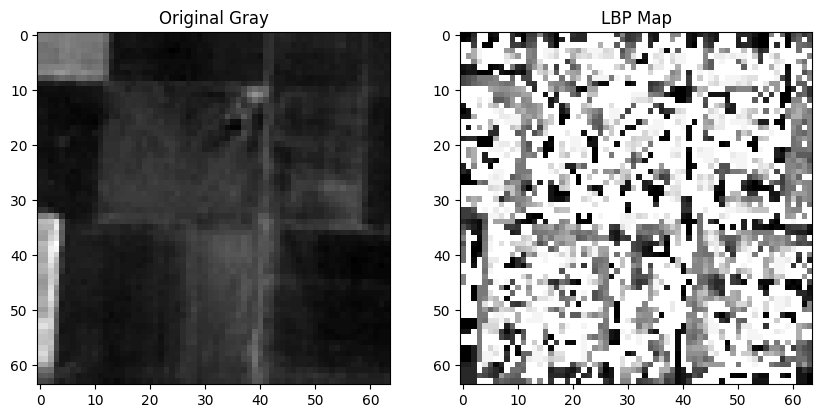

In [7]:
def plot_lbp(img_path):
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    radius = 3
    n_points = 8 * radius
    lbp = local_binary_pattern(img, n_points, radius, method='uniform')
    
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1); plt.imshow(img, cmap='gray'); plt.title('Original Gray')
    plt.subplot(1, 2, 2); plt.imshow(lbp, cmap='gray'); plt.title('LBP Map')
    plt.show()

plot_lbp(test_img)

## 3. Shape Analysis: HOG
Histogram of Oriented Gradients (HOG) captures edge directions and local shapes.

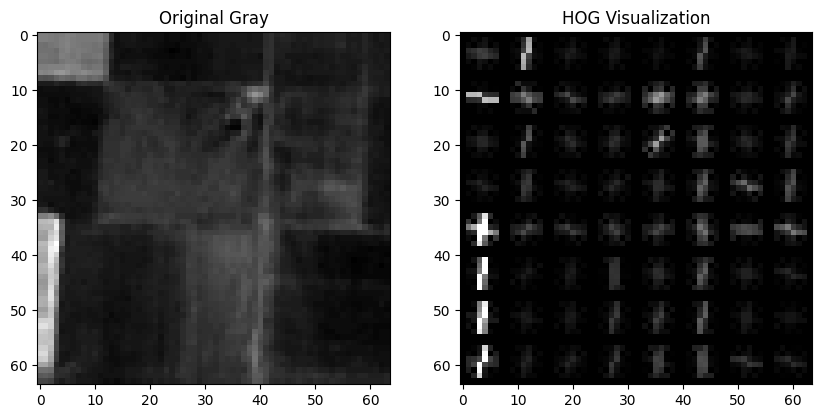

In [8]:
def plot_hog(img_path):
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    # channel_axis=None is used for grayscale images in newer skimage versions
    fd, hog_image = hog(img, orientations=8, pixels_per_cell=(8, 8),
                    cells_per_block=(1, 1), visualize=True)
    
    hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))
    
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1); plt.imshow(img, cmap='gray'); plt.title('Original Gray')
    plt.subplot(1, 2, 2); plt.imshow(hog_image_rescaled, cmap='gray'); plt.title('HOG Visualization')
    plt.show()

plot_hog(test_img)